<a href="https://colab.research.google.com/github/tanjun8802/Mase_EDGE/blob/jtan%2Fdev/EDGE_NAS_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 5: Neural Architecture Search (NAS) with Mase and Optuna

In this tutorial, we'll see how Mase can be integrated with Optuna, the popular hyperparameter optimization framework, to search for a Bert model optimized for sequence classification on the IMDb dataset. We'll take the Optuna-generated model and import it into Mase, then run the CompressionPipeline to prepare the model for edge deployment by quantizing and pruning its weights.

As we'll see, running Architecture Search with Mase/Optuna involves the following steps.

1. **Define the search space**: this is a dictionary containing the range of values for each parameter at each layer in the model.

2. **Write the model constructor**: this is a function which uses Optuna utilities to sample a model from the search space, and constructs the model using transformers from_config class method.

3. **Write the objective function**: this function calls on the model constructor defined in Step 2 and defines the training/evaluation setup for each search iteration.

4. **Go!** Choose an Optuna sampler, create a study and launch the search.

In [ ]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

In [ ]:
# If you haven't already
!git clone https://github.com/tanjun8802/mase.git
%cd mase

# Install the Python package from this repo
!pip install -e .

Cloning into 'mase'...
remote: Enumerating objects: 12048, done.
remote: Counting objects: 100% (419/419), done.
remote: Compressing objects: 100% (242/242), done.
remote: Total 12048 (delta 279), reused 201 (delta 175), pack-reused 11629 (from 3)
Receiving objects: 100% (12048/12048), 14.96 MiB | 17.10 MiB/s, done.
Resolving deltas: 100% (6954/6954), done.
/content/mase
Obtaining file:///content/mase
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Cloning https://github.com/hyperopt/hyperopt.git to /tmp/pip-install-mxfw72s0/hyperopt_66d24dd7666f473ea24f1584659bf815
  Running command git clone --filter=blob:none --quiet https://github.com/hyperopt/hyperopt.git /tmp/pip-install-mxfw72s0/hyperopt_66d24dd7666f473ea24f1584659bf815
  Resolved https://github.com/hyperopt/hyperopt.git to commit 0658f680c84a313eaffe1771a20dfe2ebabd7fd

First, fetch the dataset using the `get_tokenized_dataset` utility.

In [ ]:
from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/content/mase/src/chop/passes/graph/transforms/verilog/util.py:29: SyntaxWarning: invalid escape sequence '\<'
  Parses parameter keys of the format "[\<n\>:\<n\>] \<param\> [\<n\>:\<n\>]", where
INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` doe

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

## 1. Defining the Search Space

We'll start by defining a search space, i.e. enumerating the possible combinations of hyperparameters that Optuna can choose during search. We'll explore the following range of values for the model's hidden size, intermediate size, number of layers and number of heads, inspired by the [NAS-BERT paper](https://arxiv.org/abs/2105.14444).

In [ ]:
import torch.nn as nn
from chop.nn.modules import Identity

search_space = {
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choices": [
        nn.Linear,
        Identity,
    ],
}

## 2. Writing a Model Constructor

We define the following function, which will get called in each iteration of the search process. The function is passed the `trial` argument, which is an Optuna object that comes with many functionalities - see the [Trial documentation](https://optuna.readthedocs.io/en/stable/reference/trial.html) for more details. Here, we use the `trial.suggest_int` and `trial.suggest_categorical` functions to trigger the chosen sampler to choose parameter choices and layer types. The suggested integer is the index into the search space for each parameter, which we defined in the previous cell.

In [ ]:
from transformers import AutoConfig, AutoModelForSequenceClassification
from chop.tools.utils import deepsetattr

def make_identity_linear(dim: int) -> nn.Linear:
    """
    MASE-compatible replacement for nn.Identity().
    Acts as an identity transform but remains a 'linear' mase_op.
    """
    layer = nn.Linear(dim, dim, bias=False)
    nn.init.eye_(layer.weight)
    layer.weight.requires_grad_(False)
    return layer


def construct_model(trial):
    # Load base config
    config = AutoConfig.from_pretrained(checkpoint)

    # -----------------------------
    # 1. GLOBAL ARCHITECTURE PARAMS
    # (must all be in GridSampler search_space)
    # -----------------------------
    for param in [
        "num_layers",
        "num_heads",
        "hidden_size",
        "intermediate_size",
    ]:
        value = trial.suggest_categorical(param, search_space[param])
        setattr(config, param, value)

    # -----------------------------
    # 2. VALIDITY CONSTRAINTS
    # -----------------------------
    # BERT requirement: hidden_size divisible by num_heads
    if config.hidden_size % config.num_heads != 0:
        raise optuna.TrialPruned()

    # -----------------------------
    # 3. BUILD MODEL
    # -----------------------------
    trial_model = AutoModelForSequenceClassification.from_config(config)

    # -----------------------------
    # 4. DETERMINISTIC LAYER REWRITE
    # (NO dynamic trial parameters)
    # -----------------------------
    # Example rule:
    # Replace square Linear layers with Identity
    # This keeps the model grid-static
    for name, layer in trial_model.named_modules():
        if (
            isinstance(layer, nn.Linear)
            and layer.in_features == layer.out_features
        ):
            deepsetattr(
                trial_model,
                name,
                make_identity_linear(layer.in_features),
            )

    return trial_model



## 3. Defining the Objective Function

Next, we define the objective function for the search, which gets called on each trial. In each trial, we create a new model instace with chosen hyperparameters according to the defined sampler. We then use the `get_trainer` utility in Mase to run a training loop on the IMDb dataset for a number of epochs. Finally, we use `evaluate` to report back the classification accuracy on the test split.

In [ ]:
from chop.tools import get_trainer


def objective(trial):

    # Define the model
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    # Set the model as an attribute so we can fetch it later
    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]

## 4. Launching the Search

Optuna provides a number of samplers, for example:

* **GridSampler**: iterates through every possible combination of hyperparameters in the search space
* **RandomSampler**: chooses a random combination of hyperparameters in each iteration
* **TPESampler**: uses Tree-structured Parzen Estimator algorithm to choose hyperparameter values.

You can define the chosen sampler by simply importing from `optuna.samplers` as below.

In [ ]:
from optuna.samplers import GridSampler, RandomSampler, TPESampler

sampler = GridSampler(search_space)

/tmp/ipython-input-3157523948.py:3: UserWarning: linear_layer_choices contains a value with the type of <class 'type'>, which is not supported by `GridSampler`. Please make sure a value is `str`, `int`, `float`, `bool` or `None` for persistent storage.
  sampler = GridSampler(search_space)


With all the pieces in place, we can launch the search as follows. The number of trials is set to 1 so you can go get a coffee for 10 minutes, then proceed with the tutorial. However, this will essentially be a random model - for better results, set this to 100 and leave it running overnight!

In [ ]:
import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=4,
    timeout=60 * 60 * 24,
)

[I 2026-01-31 21:45:43,798] A new study created in memory with name: bert-tiny-nas-study
/content/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.700500
1000,0.697600
1500,0.646700
2000,0.559900
2500,0.518700
3000,0.490500


[I 2026-01-31 21:48:49,466] Trial 0 finished with value: 0.79136 and parameters: {'num_layers': 8, 'num_heads': 2, 'hidden_size': 384, 'intermediate_size': 1536}. Best is trial 0 with value: 0.79136.
/content/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.693100
1000,0.672500
1500,0.579800
2000,0.506700
2500,0.474800
3000,0.482900


[I 2026-01-31 21:50:27,917] Trial 1 finished with value: 0.7958 and parameters: {'num_layers': 8, 'num_heads': 2, 'hidden_size': 192, 'intermediate_size': 512}. Best is trial 1 with value: 0.7958.
/content/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.695500
1000,0.636400
1500,0.511000
2000,0.464100
2500,0.431500
3000,0.445000


[I 2026-01-31 21:52:36,757] Trial 2 finished with value: 0.82484 and parameters: {'num_layers': 8, 'num_heads': 8, 'hidden_size': 192, 'intermediate_size': 2048}. Best is trial 2 with value: 0.82484.
/content/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.702700
1000,0.665700
1500,0.520700
2000,0.448500
2500,0.416600
3000,0.402500


[I 2026-01-31 21:56:02,312] Trial 3 finished with value: 0.8456 and parameters: {'num_layers': 8, 'num_heads': 16, 'hidden_size': 384, 'intermediate_size': 2048}. Best is trial 3 with value: 0.8456.


Fetch the model associated with the best trial as follows, and export to be used in future tutorials. In Tutorial 6, we'll see how to run mixed-precision quantization search on top of the model we've just found through NAS to further find the optimal quantization mapping.

In [ ]:
from pathlib import Path
import dill

# model = study.best_trial.user_attrs["model"].cpu()

# with open(f"{Path.home()}/tutorial_5_best_model.pkl", "wb") as f:
#     dill.dump(model, f)

model = study.best_trial.user_attrs["model"].cpu()
with open(f"/content/tutorial_5_best_model_final.pkl", "wb") as f:
    dill.dump(model, f)

## Deploying the Optimized Model with CompressionPipeline

Now, we can run the CompressionPipeline in Mase to run uniform quantization and pruning over the searched model.

In [ ]:
from chop.pipelines import CompressionPipeline
from chop import MaseGraph

mg = MaseGraph(model)
pipe = CompressionPipeline()

quantization_config = {
    "by": "type",
    "default": {
        "config": {
            "name": None,
        }
    },
    "linear": {
        "config": {
            "name": "integer",
            # data
            "data_in_width": 8,
            "data_in_frac_width": 4,
            # weight
            "weight_width": 8,
            "weight_frac_width": 4,
            # bias
            "bias_width": 8,
            "bias_frac_width": 4,
        }
    },
}

pruning_config = {
    "weight": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
    "activation": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
}

mg, _ = pipe(
    mg,
    pass_args={
        "quantize_transform_pass": quantization_config,
        "prune_transform_pass": pruning_config,
    },
)

`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
INFO     Getting dummy input for prajjwal1/bert-tiny.


tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]],


        [[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]]])
tensor([[[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
   

INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


Finally, export the MaseGraph for the compressed checkpoint to be used in future tutorials for hardware generation and distributed deployment.

In [ ]:
mg.export(f"{Path.home()}/tutorial_5_nas_compressed", save_format="state_dict")

In [ ]:
from pathlib import Path

out_dir = Path("/content") / "tutorial_5_nas_compressed"
mg.export(str(out_dir), save_format="state_dict")


INFO     Exporting MaseGraph to /content/tutorial_5_nas_compressed.pt, /content/tutorial_5_nas_compressed.mz
INFO     Exporting GraphModule to /content/tutorial_5_nas_compressed.pt
INFO     Saving state_dict format
INFO     Exporting MaseMetadata to /content/tutorial_5_nas_compressed.mz
WARNING  Failed to pickle call_function node: finfo
WARNING  cannot pickle 'torch.finfo' object
WARNING  Failed to pickle call_function node: getattr_3
WARNING  cannot pickle 'torch.finfo' object


/tmp/ipython-input-1659257106.py:9: UserWarning: linear_layer_choices contains a value with the type of <class 'type'>, which is not supported by `GridSampler`. Please make sure a value is `str`, `int`, `float`, `bool` or `None` for persistent storage.
  grid_sampler   = GridSampler(search_space)
[I 2026-01-31 20:17:24,348] A new study created in memory with name: bert-tiny-nas-RandomSampler


config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

/content/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.693600
1000,0.652400
1500,0.530400
2000,0.476700
2500,0.455700
3000,0.452400


[I 2026-01-31 20:19:00,205] Trial 0 finished with value: 0.81736 and parameters: {'num_layers': 4, 'num_heads': 4, 'hidden_size': 192, 'intermediate_size': 768}. Best is trial 0 with value: 0.81736.
/content/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

[I 2026-01-31 20:57:51,763] Trial 22 finished with value: 0.83048 and parameters: {'num_layers': 2, 'num_heads': 8, 'hidden_size': 256, 'intermediate_size': 1024}. Best is trial 1 with value: 0.8456.
/content/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.699300
1000,0.697900
1500,0.696800
2000,0.689300
2500,0.658700
3000,0.639000


[I 2026-01-31 21:00:00,773] Trial 23 finished with value: 0.68224 and parameters: {'num_layers': 2, 'num_heads': 4, 'hidden_size': 512, 'intermediate_size': 512}. Best is trial 1 with value: 0.8456.
/content/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.702700
1000,0.665700
1500,0.520700
2000,0.448500
2500,0.416600
3000,0.402500


[I 2026-01-31 21:03:03,011] Trial 24 finished with value: 0.8456 and parameters: {'num_layers': 8, 'num_heads': 2, 'hidden_size': 384, 'intermediate_size': 2048}. Best is trial 1 with value: 0.8456.


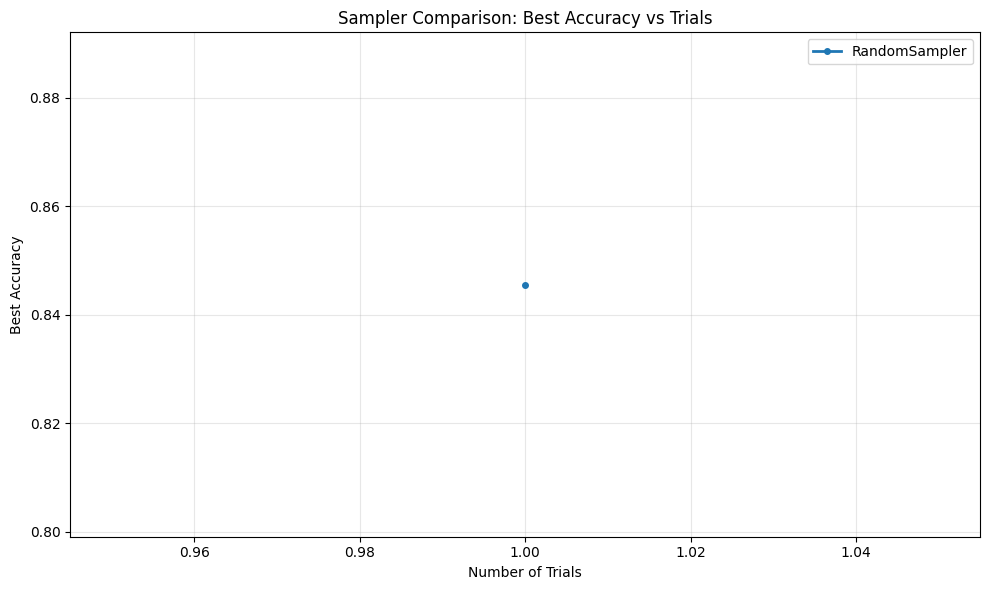

In [ ]:
# Code for Lab 2 Task 1
from chop.pipelines import CompressionPipeline
from chop import MaseGraph
import optuna
from optuna.samplers import GridSampler, RandomSampler, TPESampler
import dill
import matplotlib.pyplot as plt

grid_sampler   = GridSampler(search_space)
tpe_sampler    = TPESampler()
random_sampler = RandomSampler()

samplers      = [grid_sampler, tpe_sampler, random_sampler]
sampler_names = ["GridSampler"RandomSampler"]

# For plotting: sampler_name -> list of best accuracies vs max_trials
sampler_curves = {name: [] for name in sampler_names}

# -------------------------
# Main loop: keep your idea
# -------------------------

for s, s_name in zip(samplers, sampler_names):

    # New study for each (sampler, max_trials) pair
    study = optuna.create_study(
        direction="maximize",
        study_name=f"bert-tiny-nas-{s_name}",
        sampler=s,
    )

    study.optimize(
        objective,
        n_trials=25,        # run EXACTLY max_trials trials
        timeout=60 * 60 * 24,
    )

    # Best accuracy after 'max_trials' trials
    best_acc = study.best_value
    sampler_curves[s_name].append(best_acc)

    best_trial = study.best_trial
    best_params = study.best_params
    values = [t.value for t in study.trials]

    # Optional: save current best model
    model = study.best_trial.user_attrs["model"].cpu()
    with open(f"/content/tutorial_5_best_model_{s_name}.pkl", "wb") as f:
        dill.dump(model, f)

        # Optional: compression pipeline (unchanged)
# mg = MaseGraph(model)
# pipe = CompressionPipeline()

# quantization_config = {
#     "by": "type",
#     "default": {"config": {"name": None}},
#     "linear": {
#         "config": {
#             "name": "integer",
#             "data_in_width": 8,
#             "data_in_frac_width": 4,
#             "weight_width": 8,
#             "weight_frac_width": 4,
#             "bias_width": 8,
#             "bias_frac_width": 4,
#         }
#     },
# }

# pruning_config = {
#     "weight": {
#         "sparsity": 0.5,
#         "method": "l1-norm",
#         "scope": "local",
#     },
#     "activation": {
#         "sparsity": 0.5,
#         "method": "l1-norm",
#         "scope": "local",
#     },
# }

# mg, _ = pipe(
#     mg,
#     pass_args={
#         "quantize_transform_pass": quantization_config,
#         "prune_transform_pass": pruning_config,
#     },
# )

# # -------------------------
# # Plot: max_trials vs best accuracy
# # -------------------------

plt.figure(figsize=(10, 6))

for s_name in sampler_names:
    trials = list(range(1, len(sampler_curves[s_name]) + 1))
    plt.plot(trials, sampler_curves[s_name],
             marker='o', label=s_name, linewidth=2, markersize=4)

plt.xlabel('Number of Trials')
plt.ylabel('Best Accuracy')
plt.title('Sampler Comparison: Best Accuracy vs Trials')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


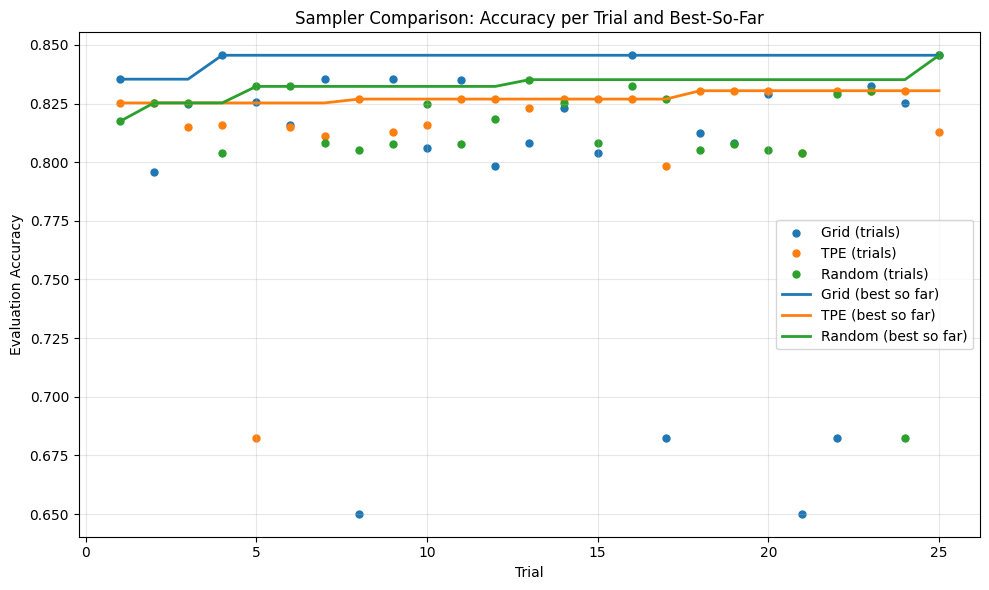

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---- 1. Enter your data ----
trials = np.arange(1, 26)

grid = np.array([
    0.8354, 0.7958, 0.8248, 0.8456, 0.8258,
    0.8159, 0.8354, 0.6501, 0.8354, 0.80596,
    0.8352, 0.79848, 0.80832, 0.82316, 0.80384,
    0.8456, 0.68224, 0.81228, 0.80832, 0.82888,
    0.65016, 0.68224, 0.83232, 0.82528, 0.8456
])

tpe = np.array([
    0.82528, 0.82528, 0.81484, 0.81592, 0.68224,
    0.81484, 0.81116, 0.82692, 0.81304, 0.81592,
    0.82692, 0.82692, 0.82316, 0.82692, 0.82692,
    0.82692, 0.79848, 0.83048, 0.83048, 0.83048,
    0.80384, 0.83048, 0.83048, 0.83048, 0.81304
])

rand = np.array([
    0.81736, 0.82528, 0.82528, 0.80384, 0.83232,
    0.83232, 0.80832, 0.80512, 0.80764, 0.82484,
    0.80764, 0.8184, 0.8352, 0.82528, 0.80832,
    0.83232, 0.82692, 0.80512, 0.80764, 0.80512,
    0.80384, 0.82888, 0.83048, 0.68224, 0.8456
])

# ---- 2. Cumulative best curves ----
grid_best = np.maximum.accumulate(grid)
tpe_best = np.maximum.accumulate(tpe)
rand_best = np.maximum.accumulate(rand)

# ---- 3. Plot: dots + best-accuracy lines ----
plt.figure(figsize=(10, 6))

# Scatter: raw trial accuracies
plt.scatter(trials, grid,  color='tab:blue',  s=25, label='Grid (trials)')
plt.scatter(trials, tpe,   color='tab:orange', s=25, label='TPE (trials)')
plt.scatter(trials, rand,  color='tab:green', s=25, label='Random (trials)')

# Lines: cumulative best accuracy
plt.plot(trials, grid_best, color='tab:blue',  linewidth=2, linestyle='-',  label='Grid (best so far)')
plt.plot(trials, tpe_best,  color='tab:orange',linewidth=2, linestyle='-',  label='TPE (best so far)')
plt.plot(trials, rand_best, color='tab:green', linewidth=2, linestyle='-',  label='Random (best so far)')

plt.xlabel('Trial')
plt.ylabel('Evaluation Accuracy')
plt.title('Sampler Comparison: Accuracy per Trial and Best-So-Far')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
